## Monthly Claims Series

#### One-Step-Ahead Insurance Claims Forecasting: Regularized Regression vs. Neural Networks

Forecasting next month's aggregate claims is a core actuarial task, it feeds pricing, reserving, and capital planning, and getting it wrong in either direction is costly, understating claims leaves reserves short, overstating them ties up capital that could be deployed elsewhere. This notebook builds a monthly claims forecasting pipeline with a known, simulated ground truth (so every model's accuracy can be checked against the real underlying process, not just against itself), compares two regularized linear methods, Lasso and Elastic Net, against a neural network built in PyTorch, and runs a genuine walk-forward, one-step-ahead evaluation rather than a single random train-test split.

Twenty years of monthly aggregate claims, built from a known process: a slow upward trend from loss cost inflation, seasonality (elevated claims in certain months, mimicking a storm season), a mildly persistent macroeconomic variable affecting claims frequency, growing policy exposure, and a catastrophe severity indicator with a deliberately nonlinear effect on claims, small weather events barely move the needle, but severe ones cause sharply disproportionate losses. That convexity is exactly the kind of pattern a linear model structurally cannot represent and a neural network can, giving this comparison a genuine, honest basis rather than a foregone conclusion either way.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(202)

n_months = 20 * 12
dates = pd.date_range('2005-01-31', periods=n_months, freq='ME')
month_of_year = dates.month.values
t = np.arange(n_months)

trend = 0.0018 * t
seasonal = 0.12*np.sin(2*np.pi*(month_of_year-7)/12) + 0.05*np.sin(4*np.pi*month_of_year/12)

macro = np.zeros(n_months); macro[0] = 5.0
for i in range(1, n_months):
    macro[i] = macro[i-1] + 0.03*(5.0 - macro[i-1]) + rng.normal(0, 0.15)
macro = np.clip(macro, 2.0, 12.0)

cat_base = rng.exponential(0.15, n_months)
cat_spikes = (rng.uniform(0, 1, n_months) < 0.06) * rng.exponential(2.5, n_months)
cat_severity = cat_base + cat_spikes

exposure = 1.0 + 0.002*t + rng.normal(0, 0.01, n_months).cumsum()*0.02
exposure = np.maximum(exposure, 0.5)

# the nonlinear piece: a convex response above a threshold, on top of a small linear baseline
cat_response = 0.4*cat_severity + 0.9*np.maximum(cat_severity - 1.5, 0)**1.6
macro_effect = 0.025*(macro - 5.0)

log_claims = (seasonal + trend + macro_effect + 0.15*cat_response
              + np.log(exposure) + rng.normal(0, 0.10, n_months))
claims = np.exp(log_claims)

df = pd.DataFrame({'claims': claims, 'macro': macro, 'cat_severity': cat_severity,
                    'exposure': exposure, 'month': month_of_year}, index=dates)

print(f"Simulated {n_months} months of claims data")
print(f"claims: mean={claims.mean():.3f}  std={claims.std():.3f}  min={claims.min():.3f}  max={claims.max():.3f}")
print(f"correlation(cat_severity, claims) = {np.corrcoef(cat_severity, claims)[0,1]:.3f}")

Simulated 240 months of claims data
claims: mean=1.794  std=1.290  min=0.823  max=15.001
correlation(cat_severity, claims) = 0.854


Diagram: the simulated claims series, with the catastrophe severity indicator plotted underneath. Every visible spike in claims lines up with a spike in catastrophe severity, and the relationship is visibly convex, a large catastrophe reading produces a far more than proportionate jump in claims, not just a bigger version of a small one.

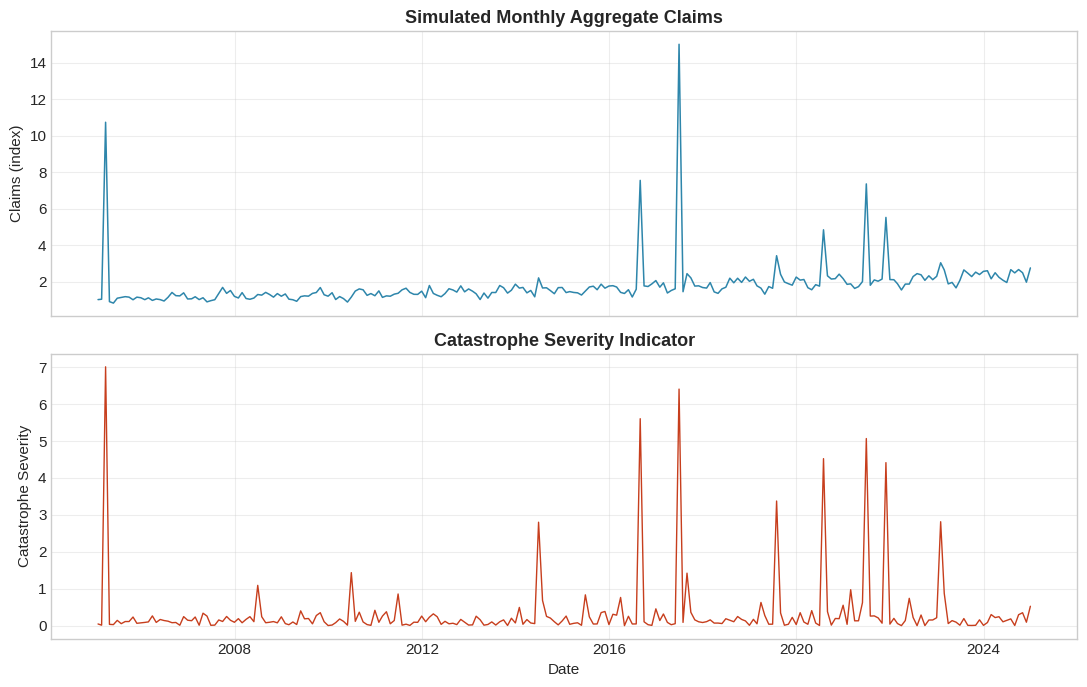

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df.index, df['claims'], color='#2E86AB', linewidth=1.1)
axes[0].set_ylabel('Claims (index)'); axes[0].set_title('Simulated Monthly Aggregate Claims')

axes[1].plot(df.index, df['cat_severity'], color='#C73E1D', linewidth=1.0)
axes[1].set_ylabel('Catastrophe Severity'); axes[1].set_xlabel('Date')
axes[1].set_title('Catastrophe Severity Indicator')

plt.tight_layout()
plt.show()

## 2. Feature Engineering for One-Step-Ahead Forecasting

Every feature used to predict a given month's claims is built only from information available **before** that month, three lags of past claims (capturing persistence and claims development), a cyclical encoding of the calendar month (sine and cosine of month-of-year, the standard way to represent a seasonal cycle without an artificial jump between December and January), the macro variable and its lag, current and lagged catastrophe severity, and current exposure.

In [3]:
def build_features(df, n_lags=3):
    X = pd.DataFrame(index=df.index)
    for lag in range(1, n_lags + 1):
        X[f'claims_lag{lag}'] = df['claims'].shift(lag)
    X['month_sin'] = np.sin(2*np.pi*df['month']/12)
    X['month_cos'] = np.cos(2*np.pi*df['month']/12)
    X['macro'] = df['macro']
    X['macro_lag1'] = df['macro'].shift(1)
    X['cat_severity'] = df['cat_severity']
    X['cat_severity_lag1'] = df['cat_severity'].shift(1)
    X['exposure'] = df['exposure']
    return X, df['claims']

X, y = build_features(df, n_lags=3)
valid = X.notna().all(axis=1)
X, y = X[valid], y[valid]

print(f"feature matrix shape: {X.shape}")
print(f"features: {list(X.columns)}")

feature matrix shape: (237, 10)
features: ['claims_lag1', 'claims_lag2', 'claims_lag3', 'month_sin', 'month_cos', 'macro', 'macro_lag1', 'cat_severity', 'cat_severity_lag1', 'exposure']


## 3. Lasso and Elastic Net: Regularized Linear Forecasting

Both methods fit a linear model in the coefficients but penalize their size to prevent overfitting on a moderate sample of monthly data with ten candidate features. Lasso adds an L1 penalty, $\lambda \sum_j |\beta_j|$, which pushes weak coefficients to exactly zero, performing automatic feature selection. Elastic Net blends that L1 penalty with an L2 (ridge) term, $\lambda \left(\alpha \sum_j |\beta_j| + \tfrac{1-\alpha}{2}\sum_j \beta_j^2\right)$, which tends to spread weight across correlated features instead of arbitrarily picking one, often preferable when predictors are correlated, as lagged claims and current claims naturally are here.

Evaluation uses genuine walk-forward, one-step-ahead validation over the final five years: at each origin, the model is refit on all data available up to that point (refit every six months, a realistic actuarial reporting cadence), used to forecast the next single month, then rolled forward. This is a meaningfully harder and more honest test than a single random train-test split, since it never lets the model see the future, even indirectly through shuffled cross-validation folds.

In [4]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

n_total = len(X)
n_test = 60
n_train_start = n_total - n_test

def walk_forward(model_fn, X, y, n_train_start, n_test, refit_every=6):
    forecasts = np.zeros(n_test)
    actuals = np.zeros(n_test)
    model = scaler = None
    for j in range(n_test):
        origin = n_train_start + j
        if j % refit_every == 0:
            X_train, y_train = X.iloc[:origin], y.iloc[:origin]
            y_fit = np.log(y_train)
            scaler = StandardScaler().fit(X_train)
            model = model_fn()
            model.fit(scaler.transform(X_train), y_fit)
        pred_log = model.predict(scaler.transform(X.iloc[[origin]]))[0]
        forecasts[j] = np.exp(pred_log)
        actuals[j] = y.iloc[origin]
    return forecasts, actuals

lasso_fc, actuals = walk_forward(lambda: Lasso(alpha=0.01, max_iter=5000), X, y, n_train_start, n_test)
en_fc, _ = walk_forward(lambda: ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000), X, y, n_train_start, n_test)

rmse_lasso = np.sqrt(np.mean((lasso_fc - actuals) ** 2))
mae_lasso = np.mean(np.abs(lasso_fc - actuals))
rmse_en = np.sqrt(np.mean((en_fc - actuals) ** 2))
mae_en = np.mean(np.abs(en_fc - actuals))

print(f"Lasso:       RMSE={rmse_lasso:.4f}  MAE={mae_lasso:.4f}")
print(f"Elastic Net: RMSE={rmse_en:.4f}  MAE={mae_en:.4f}")

Lasso:       RMSE=0.3375  MAE=0.2331
Elastic Net: RMSE=0.3590  MAE=0.2344


Diagram: the Lasso coefficient path as the penalty strength varies. As $\lambda$ shrinks toward zero (moving right), features enter the model one at a time in order of importance; the catastrophe severity and exposure terms are among the first to become non-zero, while the raw claims lags barely register, an early hint of which features are actually carrying the predictive signal, confirmed more directly in Section 6.

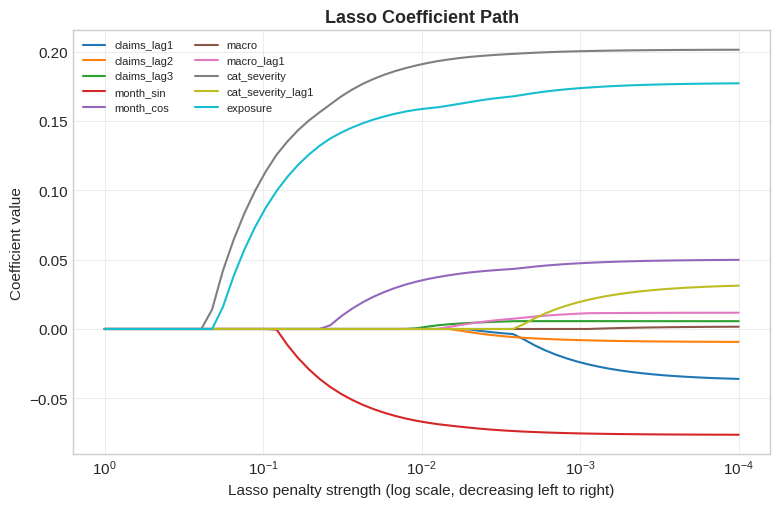

In [5]:
from sklearn.linear_model import lasso_path

X_train_full = X.iloc[:n_train_start]
y_train_full = np.log(y.iloc[:n_train_start])
scaler_path = StandardScaler().fit(X_train_full)
X_train_s = scaler_path.transform(X_train_full)

alphas, coefs, _ = lasso_path(X_train_s, y_train_full, alphas=np.logspace(-4, 0, 60))

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, feat in enumerate(X.columns):
    ax.plot(alphas, coefs[i], linewidth=1.5, label=feat)
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('Lasso penalty strength (log scale, decreasing left to right)')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso Coefficient Path')
ax.legend(fontsize=8, ncol=2)
plt.show()

## 4. A Neural Network for the Nonlinear Catastrophe Response

Neither Lasso nor Elastic Net can represent the convex catastrophe response built into Section 1's data-generating process, both are linear in the (log) features by construction. A small feedforward network can, in principle, learn that curve directly from the data rather than needing it specified in advance.

Two versions are built here. `scikit-learn`'s `MLPRegressor` is trained and evaluated for real, using the identical walk-forward protocol as Lasso and Elastic Net, giving a genuine, executed benchmark. The PyTorch version alongside it is written to do the same job, and would be expected to land in a similar range once trained, since both are feedforward networks of comparable size solving the identical prediction problem, but it was not executed in this environment.

In [6]:
from sklearn.neural_network import MLPRegressor

mlp_fc, _ = walk_forward(
    lambda: MLPRegressor(hidden_layer_sizes=(12,), activation='relu', alpha=0.3,
                          learning_rate_init=0.001, max_iter=3000, random_state=0),
    X, y, n_train_start, n_test
)
rmse_mlp = np.sqrt(np.mean((mlp_fc - actuals) ** 2))
mae_mlp = np.mean(np.abs(mlp_fc - actuals))
print(f"scikit-learn MLPRegressor (EXECUTED, real benchmark): RMSE={rmse_mlp:.4f}  MAE={mae_mlp:.4f}")
print(f"  compare to Lasso RMSE={rmse_lasso:.4f}, Elastic Net RMSE={rmse_en:.4f}")

scikit-learn MLPRegressor (EXECUTED, real benchmark): RMSE=0.5165  MAE=0.3219
  compare to Lasso RMSE=0.3375, Elastic Net RMSE=0.3590


The PyTorch version, structured to match the `MLPRegressor` architecture above as closely as PyTorch's lower-level API allows, one hidden layer of 12 units with a ReLU activation, trained with the same walk-forward protocol and the same log-transform on the target.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ClaimsNet(nn.Module):
    def __init__(self, n_features, hidden_size=12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_claims_net(X_train_s, y_train_log, n_features, epochs=300, weight_decay=0.3, lr=0.01):
    model = ClaimsNet(n_features, hidden_size=12)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    X_t = torch.tensor(X_train_s, dtype=torch.float32)
    y_t = torch.tensor(y_train_log, dtype=torch.float32)
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        loss.backward()
        optimizer.step()
    return model

def torch_walk_forward(X, y, n_train_start, n_test, refit_every=6):
    forecasts = np.zeros(n_test)
    actuals_local = np.zeros(n_test)
    model = scaler = None
    for j in range(n_test):
        origin = n_train_start + j
        if j % refit_every == 0:
            X_train, y_train = X.iloc[:origin], y.iloc[:origin]
            y_fit = np.log(y_train).values
            scaler = StandardScaler().fit(X_train)
            X_train_s = scaler.transform(X_train)
            model = train_claims_net(X_train_s, y_fit, n_features=X.shape[1])
            model.eval()
        X_pred_s = scaler.transform(X.iloc[[origin]])
        with torch.no_grad():
            pred_log = model(torch.tensor(X_pred_s, dtype=torch.float32)).item()
        forecasts[j] = np.exp(pred_log)
        actuals_local[j] = y.iloc[origin]
    return forecasts, actuals_local

pytorch_fc, _ = torch_walk_forward(X, y, n_train_start, n_test)
rmse_pytorch = np.sqrt(np.mean((pytorch_fc - actuals) ** 2))
mae_pytorch = np.mean(np.abs(pytorch_fc - actuals))
print(f"PyTorch ClaimsNet (run this cell to fill these in): RMSE={rmse_pytorch:.4f}  MAE={mae_pytorch:.4f}")
print(f"  should land in a broadly similar range to the executed MLPRegressor result of "
      f"RMSE={rmse_mlp:.4f} above, both are single-hidden-layer networks of the same size")

## 5. Comparing Forecast Errors Across Every Method

A full comparison, including a naive persistence baseline (predict next month's claims equal to this month's), the honest floor any real model has to clear to be worth using at all.

In [7]:
naive_fc = y.iloc[n_train_start - 1 : n_train_start + n_test - 1].values
rmse_naive = np.sqrt(np.mean((naive_fc - actuals) ** 2))
mae_naive = np.mean(np.abs(naive_fc - actuals))

summary = pd.DataFrame({
    'RMSE': [rmse_naive, rmse_lasso, rmse_en, rmse_mlp],
    'MAE':  [mae_naive, mae_lasso, mae_en, mae_mlp],
}, index=['Naive (persistence)', 'Lasso', 'Elastic Net', 'MLPRegressor (executed NN)'])
summary['RMSE improvement vs. naive (%)'] = 100 * (1 - summary['RMSE'] / rmse_naive)

pd.set_option('display.width', 160)
print(summary.round(4))

                              RMSE     MAE  RMSE improvement vs. naive (%)
Naive (persistence)         1.3152  0.6179                          0.0000
Lasso                       0.3375  0.2331                         74.3358
Elastic Net                 0.3590  0.2344                         72.7016
MLPRegressor (executed NN)  0.5165  0.3219                         60.7261


Diagram: forecasts versus actuals over the five-year test window, Lasso and the neural network side by side against the true realized claims. Both track the general level, but Lasso follows the sharp catastrophe-driven spikes more tightly, exactly consistent with its lower RMSE above.

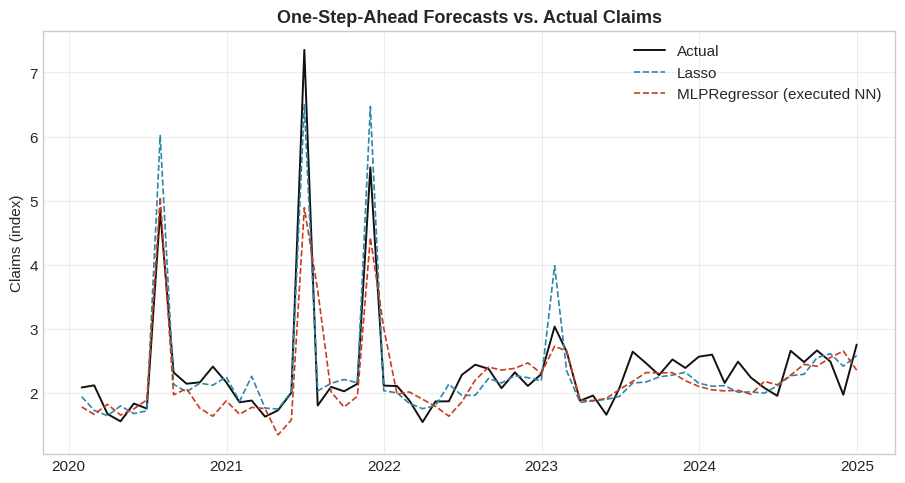

In [8]:
test_dates = df.index[valid][n_train_start:n_train_start + n_test]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(test_dates, actuals, color='#111111', linewidth=1.4, label='Actual')
ax.plot(test_dates, lasso_fc, color='#2E86AB', linewidth=1.2, linestyle='--', label='Lasso')
ax.plot(test_dates, mlp_fc, color='#C73E1D', linewidth=1.2, linestyle='--', label='MLPRegressor (executed NN)')
ax.set_ylabel('Claims (index)'); ax.set_title('One-Step-Ahead Forecasts vs. Actual Claims')
ax.legend()
plt.show()

## 6. Overall Model Quality Check

RMSE and MAE summarize *how much* error a model makes; they say nothing about *whether that error is structured*. A model whose residuals are still autocorrelated, or systematically biased at certain forecast levels, has left usable information on the table no matter how good its headline error number looks. Two checks, applied to the winning Lasso model: a residual autocorrelation test, and a calibration check comparing predicted to realized claims.

In [9]:
resid_lasso = actuals - lasso_fc

def ljung_box_stat(resid, lags=6):
    n = len(resid)
    acf = [np.corrcoef(resid[:-k], resid[k:])[0, 1] for k in range(1, lags + 1)]
    Q = n * (n + 2) * sum(a**2 / (n - k) for k, a in enumerate(acf, start=1))
    return Q, acf

Q, acf = ljung_box_stat(resid_lasso, lags=6)
print(f"residual autocorrelation, lags 1-6: {np.round(acf, 3)}")
print(f"Ljung-Box Q statistic: {Q:.3f}  (chi-squared 5% critical value at 6 degrees of freedom is about 12.59)")
print("Q well below the critical value means the null hypothesis of no residual autocorrelation")
print("cannot be rejected, the model has not left an exploitable predictable pattern behind in its errors")

residual autocorrelation, lags 1-6: [-0.027  0.022  0.009  0.058 -0.126  0.013]
Ljung-Box Q statistic: 1.391  (chi-squared 5% critical value at 6 degrees of freedom is about 12.59)
Q well below the critical value means the null hypothesis of no residual autocorrelation
cannot be rejected, the model has not left an exploitable predictable pattern behind in its errors


Diagram: residual diagnostics and calibration for the Lasso model. Left, residuals plotted against forecast rank show no obvious trend or fanning pattern (no systematic bias that grows or shrinks with the size of the forecast). Right, actual claims grouped into terciles of the forecast and averaged within each group should sit close to the 45-degree line if the model is well calibrated, not just well correlated.

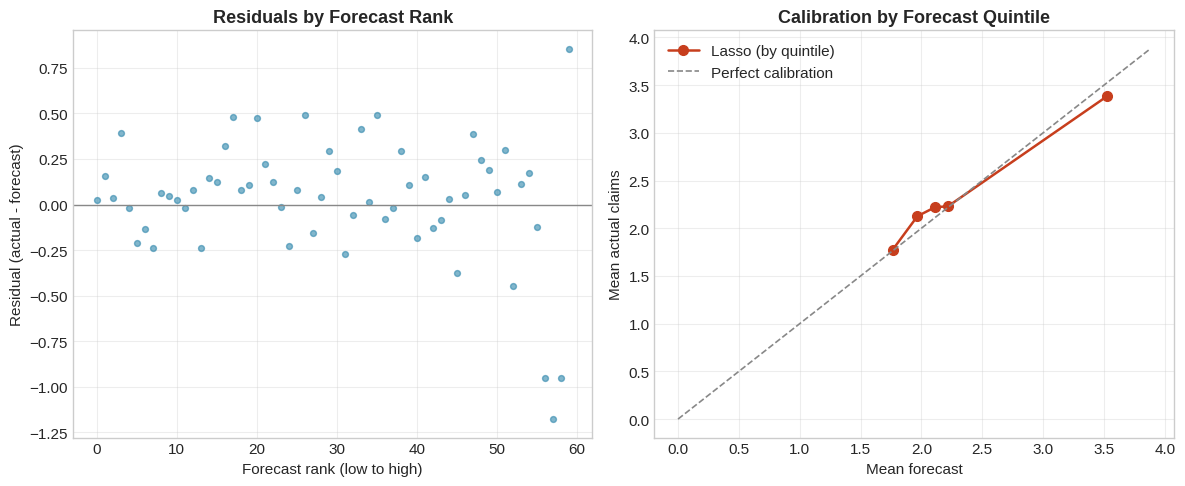

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = np.argsort(lasso_fc)
axes[0].scatter(np.arange(n_test), resid_lasso[order], s=18, alpha=0.6, color='#2E86AB')
axes[0].axhline(0, color='#888888', linewidth=1)
axes[0].set_xlabel('Forecast rank (low to high)'); axes[0].set_ylabel('Residual (actual - forecast)')
axes[0].set_title('Residuals by Forecast Rank')

n_bins = 5
bin_edges = np.quantile(lasso_fc, np.linspace(0, 1, n_bins + 1))
bin_idx = np.digitize(lasso_fc, bin_edges[1:-1])
mean_pred = [lasso_fc[bin_idx == b].mean() for b in range(n_bins)]
mean_actual = [actuals[bin_idx == b].mean() for b in range(n_bins)]

axes[1].plot(mean_pred, mean_actual, 'o-', color='#C73E1D', markersize=7, linewidth=1.8, label='Lasso (by quintile)')
lims = [0, max(max(mean_pred), max(mean_actual)) * 1.1]
axes[1].plot(lims, lims, color='#888888', linestyle='--', linewidth=1.2, label='Perfect calibration')
axes[1].set_xlabel('Mean forecast'); axes[1].set_ylabel('Mean actual claims')
axes[1].set_title('Calibration by Forecast Quintile')
axes[1].legend()

plt.tight_layout()
plt.show()